In [23]:
%%time

#libraries

import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
#from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss


from pymer4.models import Lmer

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, brier_score_loss, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score


import matplotlib.pyplot as plt
from sklearn.metrics import plot_confusion_matrix

#import seaborn as sns
#sns.set(style="white")
#sns.set(style="whitegrid", color_codes=True)

CPU times: user 104 µs, sys: 0 ns, total: 104 µs
Wall time: 114 µs


In [24]:
%%time
#read data
input_data = pd.read_excel(r'fractions2013.xlsx')


input_data.head()

CPU times: user 4.11 s, sys: 7.62 ms, total: 4.12 s
Wall time: 4.12 s


,Row,Sample,AnonStudentId,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,...,Correct Step Duration (sec),Error Step Duration (sec),First Attempt,Incorrects,Hints,Corrects,Condition,KC (Default),Opportunity,Predicted Error Rate (Default)
0,1,All Data,Stu_00f382876a4ce3a5d2e9ca1a575a68a9,"Assignment F-S_Check_B-A_Test-B-A_20, ProblemS...",1,1,dragTarget1 WasJustHitByA NL,2013-05-14 14:12:49,2013-05-14 14:12:58,2013-05-14 14:13:00,...,.,11,unknown,0,0,1,F-S (Condition),compDragSmallest,1.0,0.3349
1,2,All Data,Stu_00f382876a4ce3a5d2e9ca1a575a68a9,"Assignment F-S_Check_B-A_Test-B-A_20, ProblemS...",1,1,dragTarget1 WasJustHitByA Circle,2013-05-14 14:13:00,2013-05-14 14:13:03,2013-05-14 14:13:05,...,.,5,unknown,0,0,1,F-S (Condition),equivDragFract,1.0,0.0000
2,3,All Data,Stu_00f382876a4ce3a5d2e9ca1a575a68a9,"Assignment F-S_Check_B-A_Test-B-A_20, ProblemS...",1,1,dragTarget1 WasJustHitByA Rect,2013-05-14 14:13:05,2013-05-14 14:13:13,2013-05-14 14:13:14,...,.,9,unknown,0,0,1,F-S (Condition),compDragSmallest,2.0,0.3116
3,4,All Data,Stu_00f382876a4ce3a5d2e9ca1a575a68a9,"Assignment F-S_Check_B-A_Test-B-A_20, ProblemS...",1,1,dragTarget4 WasJustHitByA NL,2013-05-14 14:13:45,2013-05-14 14:13:46,2013-05-14 14:13:51,...,.,6,unknown,0,0,1,F-S (Condition),equivDragFract,2.0,0.0000
4,5,All Data,Stu_00f382876a4ce3a5d2e9ca1a575a68a9,"Assignment F-S_Check_B-A_Test-B-A_20, ProblemS...",1,1,dragTarget2 WasJustHitByA NL,2013-05-14 14:13:26,2013-05-14 14:13:42,2013-05-14 14:13:53,...,.,21,unknown,1,0,1,F-S (Condition),equivDragFract,3.0,0.0000


Independent Variables: student id, opportunity

Dependent Variable: Outcome (1 means correct, 0 means incorrect)

In [25]:
%%time
# Feature Engineering


df=input_data
df.loc[ df['First Attempt'] == 'incorrect', 'First Attempt'] = 0
df.loc[ df['First Attempt'] == 'hint', 'First Attempt'] = 0
df.loc[ df['First Attempt'] == 'correct', 'First Attempt'] = 1

#Remove everything that is not 0 or 1

df = df[(df['First Attempt']==0) | (df['First Attempt']==1)]



#Remove N/A

df=df.dropna()
df.insert(22,'Outcome',df['First Attempt'])



## For AFM
df.rename(columns={'KC (Default)': 'KCModel', 'Opportunity': 'OpportunityModel'}, inplace=True)

## For PFM

df.rename(columns={'Corrects': 'CorrectModel', 'Incorrects': 'IncorrectModel'}, inplace=True)

## For IFM

df.rename(columns={'Hints': 'TellsModel'}, inplace=True)

CPU times: user 26.1 ms, sys: 0 ns, total: 26.1 ms
Wall time: 25.4 ms


In [26]:
%%time

yAFM, XAFM = dmatrices('Outcome ~ AnonStudentId + KCModel+ KCModel:OpportunityModel', df,return_type="dataframe")
yPFM, XPFM = dmatrices('Outcome ~ AnonStudentId + KCModel+ KCModel:(CorrectModel:IncorrectModel)', df,return_type="dataframe")
yIFM, XIFM = dmatrices('Outcome ~ AnonStudentId + KCModel+ KCModel:(CorrectModel:IncorrectModel+TellsModel)', df,return_type="dataframe")


y = df['Outcome']
y= y.astype('int')
y

CPU times: user 236 ms, sys: 7.92 ms, total: 244 ms
Wall time: 243 ms


22       0
34       0
37       1
44       1
58       1
        ..
15400    1
15401    1
15402    0
15403    0
15404    1
Name: Outcome, Length: 7935, dtype: int64

In [27]:
%%time

### Models trained using full input data

AFMTrainingModel=LogisticRegression(max_iter=1000)
AFMTrainingModel=AFMTrainingModel.fit(XAFM,y)

PFMTrainingModel=LogisticRegression(max_iter=1000)
PFMTrainingModel=PFMTrainingModel.fit(XPFM,y)

IFMTrainingModel=LogisticRegression(max_iter=1000)
IFMTrainingModel=IFMTrainingModel.fit(XIFM,y)

CPU times: user 1.17 s, sys: 19.8 ms, total: 1.19 s
Wall time: 306 ms


In [28]:
%%time
k=10
kf = KFold(n_splits=k, random_state=None)
afmACCcv = cross_val_score(AFMTrainingModel , XAFM, y, cv = kf).mean()
pfmACCcv = cross_val_score(PFMTrainingModel , XPFM, y, cv = kf).mean()
ifmACCcv = cross_val_score(IFMTrainingModel , XIFM, y, cv = kf).mean()

print(afmACCcv)
print(pfmACCcv)
print(ifmACCcv)

0.715051568986821
0.958788644976034
0.9818555623671866
CPU times: user 10.9 s, sys: 75.6 ms, total: 10.9 s
Wall time: 2.76 s


In [29]:
%%time

### Models trained using train, test split

XAFM_train, XAFM_test, yAFM_train, yAFM_test = train_test_split(XAFM, y, test_size=0.2, random_state=0)
XPFM_train, XPFM_test, yPFM_train, yPFM_test = train_test_split(XPFM, y, test_size=0.2, random_state=0)
XIFM_train, XIFM_test, yIFM_train, yIFM_test = train_test_split(XIFM, y, test_size=0.2, random_state=0)

AFMTrainingTestModel=LogisticRegression(max_iter=1000)
AFMTrainingTestModel=AFMTrainingTestModel.fit(XAFM_train,yAFM_train)

PFMTrainingTestModel=LogisticRegression(max_iter=1000)
PFMTrainingTestModel=PFMTrainingTestModel.fit(XPFM_train,yPFM_train)

IFMTrainingTestModel=LogisticRegression(max_iter=1000)
IFMTrainingTestModel=IFMTrainingTestModel.fit(XIFM_train,yIFM_train)


y_AFMpred=AFMTrainingTestModel.predict(XAFM_test)
y_PFMpred=PFMTrainingTestModel.predict(XPFM_test)
y_IFMpred=IFMTrainingTestModel.predict(XIFM_test)

afmError=np.sqrt(np.mean((yAFM_test-y_AFMpred)**2))
pfmError=np.sqrt(np.mean((yPFM_test-y_PFMpred)**2))
ifmError=np.sqrt(np.mean((yIFM_test-y_IFMpred)**2))

print("RMSE from AFM Model",afmError)
print("RMSE from PFM Model",pfmError)
print("RMSE from IFM Model",ifmError)


#print(classification_report(yAFM_test,y_AFMpred)) 
#print(classification_report(yPFM_test,y_PFMpred))
#print(classification_report(yIFM_test,y_IFMpred))



#print(f1_score(y_test, y_pred, average="macro"))
#print(precision_score(y_test, y_pred, average="macro"))
#print(recall_score(y_test, y_pred, average="macro"))

RMSE from AFM Model 0.5181032733831733
RMSE from PFM Model 0.17209191430489734
RMSE from IFM Model 0.12297509238026913
CPU times: user 966 ms, sys: 3.91 ms, total: 970 ms
Wall time: 242 ms


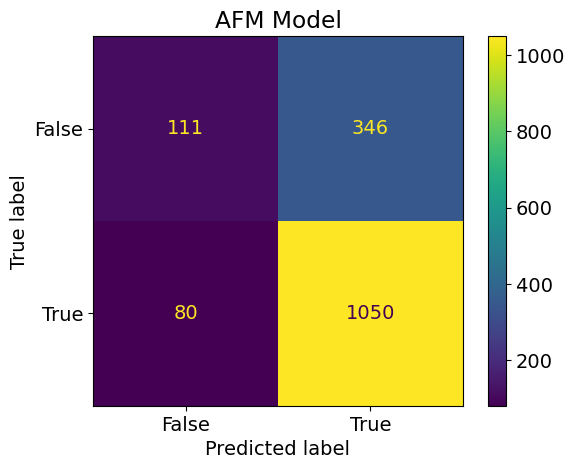

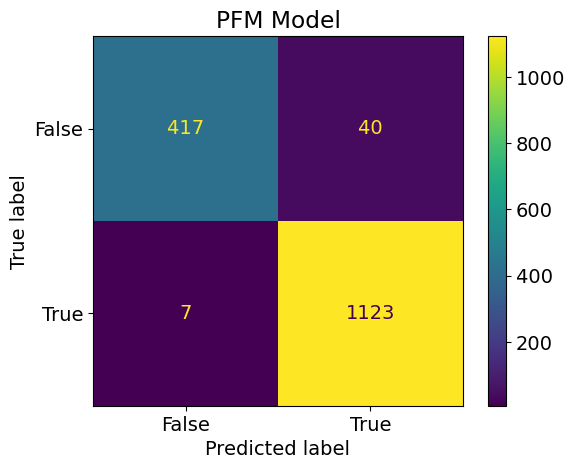

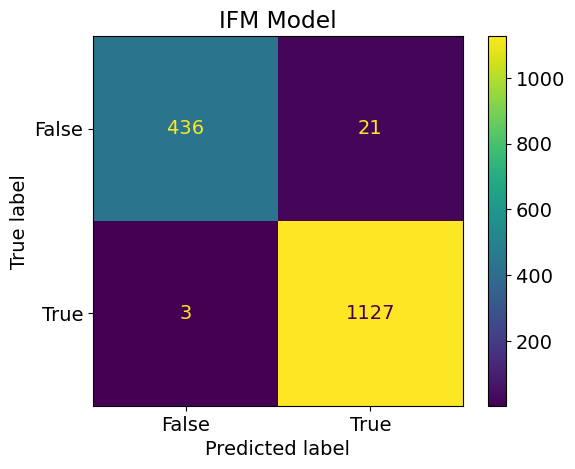

In [30]:


#print("Confusion Matrix AFM")
#print(confusion_matrix(yAFM_test, y_AFMpred))
#print("Confusion Matrix AFM")
#print(confusion_matrix(yAFM_test, y_AFMpred))

#confusion_matrix(yPFM_test, y_PFMpred)
#confusion_matrix(yIFM_test, y_IFMpred)
afmmatrix=confusion_matrix(yAFM_test, y_AFMpred)
pfmmatrix=confusion_matrix(yPFM_test, y_PFMpred)
ifmmatrix=confusion_matrix(yIFM_test, y_IFMpred)





cm_display = ConfusionMatrixDisplay(confusion_matrix = afmmatrix, display_labels = [False, True])
cm_display.plot()
plt.title("AFM Model")


cm_display = ConfusionMatrixDisplay(confusion_matrix = pfmmatrix, display_labels = [False, True])
cm_display.plot()
plt.title("PFM Model")
 

cm_display = ConfusionMatrixDisplay(confusion_matrix = ifmmatrix, display_labels = [False, True])
cm_display.plot()
plt.title("IFM Model")
plt.show() 

In [41]:
AFMCoefficients=pd.DataFrame(zip(XAFM.columns, np.transpose(AFMTrainingModel.coef_)))
PFMCoefficients=pd.DataFrame(zip(XPFM.columns, np.transpose(PFMTrainingModel.coef_)))
IFMCoefficients=pd.DataFrame(zip(XIFM.columns, np.transpose(IFMTrainingModel.coef_)))

In [32]:
%%time


def deviance(X, y, model):
    return 2*log_loss(y, model.predict_proba(X), normalize=False)

def getScores(X,y,model,df):
    y_pred_proba=model.predict_proba(X)[:,1]
    logloss=log_loss(y,y_pred_proba)
    loglikelihood=-logloss*len(y)
    K=len(model.coef_[0]) #Number Coefficients
    AIC = -2*loglikelihood+2*K
    n=len(df) #Column Number
    AICc= -2*(loglikelihood)+2*K+(2*K*(K+1)/(n-K-1))
    BIC= AIC+K*(np.log(n)-2)
    #Brier Score Loss
    brierscoreloss= brier_score_loss(y, y_pred_proba)
    values={"logloss":logloss,"K":K,
            "AIC":AIC,"AICc":AICc,"BIC":BIC,"brierscoreloss":brierscoreloss}
    return values



LikelihoodAFM=-deviance(XAFM,y,AFMTrainingModel)/2
LikelihoodPFM=-deviance(XPFM,y,PFMTrainingModel)/2
LikelihoodIFM=-deviance(XIFM,y,IFMTrainingModel)/2

AFMvalues=getScores(XAFM,y,AFMTrainingModel, df)
PFMvalues=getScores(XPFM,y,PFMTrainingModel, df)
IFMvalues=getScores(XIFM,y,IFMTrainingModel, df)

CPU times: user 130 ms, sys: 33 µs, total: 130 ms
Wall time: 34.2 ms


In [42]:
exports = pd.DataFrame(columns=["","AFM","PFM","IFM"])

entries = pd.DataFrame.from_dict(
    [{"": "RMSE", "AFM":afmError, "PFM":pfmError, "IFM":ifmError},
     {"": "ACCcv", "AFM":afmACCcv, "PFM":pfmACCcv, "IFM":ifmACCcv},
     {"": "Likelihood", "AFM":LikelihoodAFM, "PFM":LikelihoodPFM, "IFM":LikelihoodIFM},
     {"": "Log Loss", "AFM":AFMvalues["logloss"], "PFM":PFMvalues["logloss"], "IFM":IFMvalues["logloss"]},
     {"": "NumCoefficients", "AFM":AFMvalues["K"], "PFM":PFMvalues["K"], "IFM":IFMvalues["K"]},
     {"": "AIC", "AFM":AFMvalues["AIC"], "PFM":PFMvalues["AIC"], "IFM":IFMvalues["AIC"]},
     {"": "AICc", "AFM":AFMvalues["AICc"], "PFM":PFMvalues["AICc"], "IFM":IFMvalues["AICc"]},
     {"": "BIC", "AFM":AFMvalues["BIC"], "PFM":PFMvalues["BIC"], "IFM":IFMvalues["BIC"]},
     {"": "Brier Score", "AFM":AFMvalues["brierscoreloss"], "PFM":PFMvalues["brierscoreloss"], "IFM":IFMvalues["brierscoreloss"]}]


)

exports = pd.concat([exports, entries], ignore_index=True)
exports.to_csv("./Python results.csv",index=False, header=True)


#writer = pd.ExcelWriter('results.xlsx', engine='xlsxwriter')
#writer = pd.ExcelWriter('results.xlsx', engine='xlsxwriter')
#exports.to_excel(writer, sheet_name="Results")

#column_names=["","Estimate Std."]
#AFMCoefficients.columns = column_names
#PFMCoefficients.columns = column_names
#IFMCoefficients.columns = column_names

#AFMCoefficients.to_excel(writer, sheet_name="AFM Model Coefficients")
#PFMCoefficients.to_excel(writer, sheet_name="PFM Model Coefficients")
#IFMCoefficients.to_excel(writer, sheet_name="IFM Model Coefficients")


#afmmatrix = pd.DataFrame(afmmatrix).transpose()
#afmmatrix.to_excel(writer,sheet_name="AFM Confusion Matrix")
#pfmmatrix = pd.DataFrame(pfmmatrix).transpose()
#pfmmatrix.to_excel(writer,sheet_name="PFM Confusion Matrix")
#ifmmatrix = pd.DataFrame(ifmmatrix).transpose()
#ifmmatrix.to_excel(writer,sheet_name="IFM Confusion Matrix")

#writer.save()

In [ ]:
## Not working rn

"""

uniqueids=pd.unique(df['AnonStudentId'])
testing=uniqueids[0:(len(uniqueids)//3)-1]
tester=df[df["AnonStudentId"].isin(testing)]
students=pd.unique(tester['AnonStudentId'])
lmerAFM_RMSE=[]
copydf=[]
copydf=df.drop(['Step Start Time',
       'First Transaction Time', 'Correct Transaction Time', 'Step End Time',
       'Step Duration (sec)', 'Correct Step Duration (sec)',
       'Error Step Duration (sec)'], axis='columns')
i=1

for stu in students:
    stu = students[i]
    TrainingDataTemp=copydf[~copydf["AnonStudentId"].isin([stu])]
    TestingDataTemp=copydf[copydf["AnonStudentId"].isin([stu])]
    try:
        afmlmer=Lmer('Outcome ~ (1|AnonStudentId) + KCModel + KCModel:OpportunityModel',data=TrainingDataTemp,family='binomial')
        ## Work in progress
    except:
        print("Error")
        
"""

In [ ]:

"""

X_train_with_constant=sm.add_constant(X_train)
X_test_with_constant=sm.add_constant(X_test)

log_reg=sm.Logit(y_train, X_train_with_constant).fit()

print(log_reg.summary())



"""